# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Muhammad Dzaky Haidar | 5054251039 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [3]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('tab10')

In [15]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.info())
display(df.describe(include='all'))
print(df.isnull().sum())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_1861/539935490.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette='Set2')


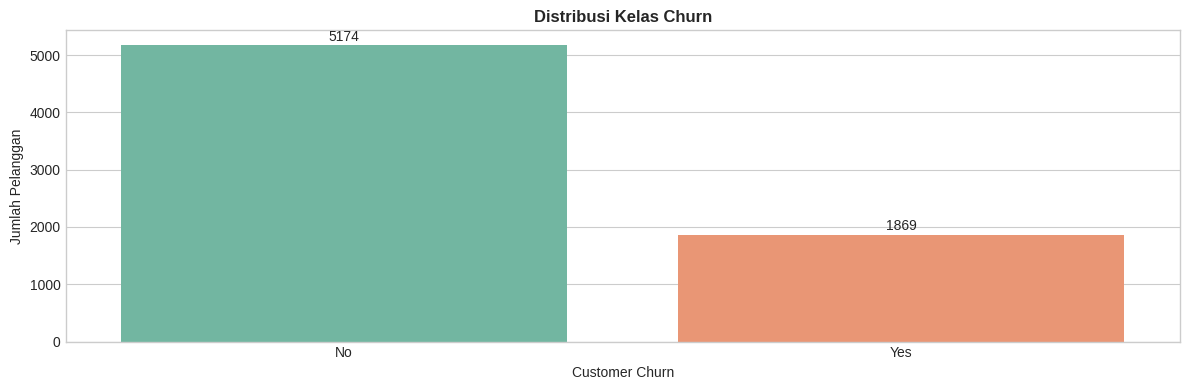

Proporsi Distribusi Target:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [10]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

target_col = 'Churn'

plt.figure(figsize=(12, 4))
ax = sns.countplot(x=target_col, data=df, palette='Set2')
plt.title('Distribusi Kelas Churn', fontsize=12,fontweight='bold')
plt.xlabel('Customer Churn')
plt.ylabel('Jumlah Pelanggan')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=10, xytext=(0,3), textcoords='offset points')

plt.tight_layout()
plt.show()

print("Proporsi Distribusi Target:")
print(df[target_col].value_counts(normalize=True) * 100)

/tmp/ipykernel_1861/3518224906.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette='Set2')
/tmp/ipykernel_1861/3518224906.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette='Set2')
/tmp/ipykernel_1861/3518224906.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette='Set2')


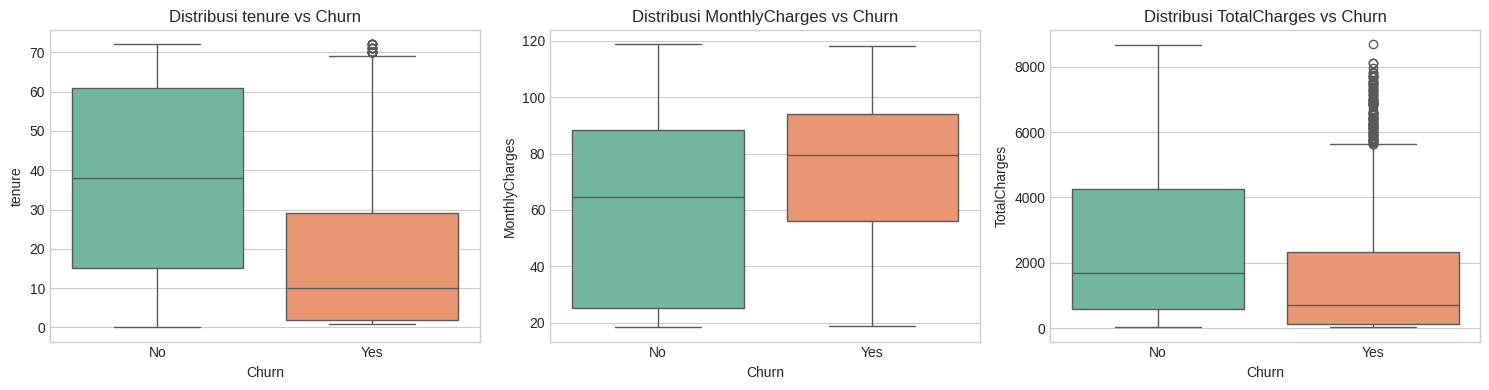

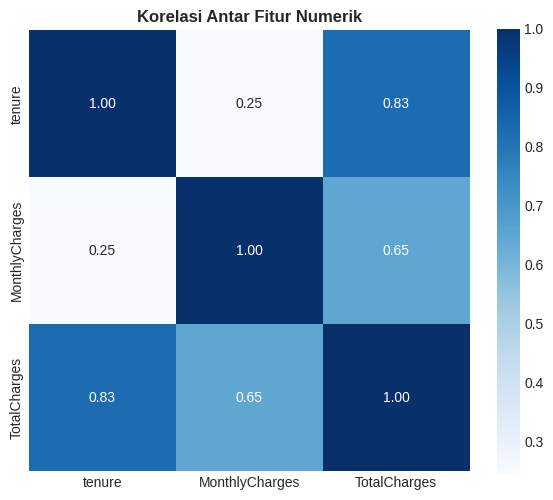

In [16]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1,3,i)
    sns.boxplot(x=target_col, y=col, data=df, palette='Set2')
    plt.title(f'Distribusi {col} vs Churn')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True)
plt.title('Korelasi Antar Fitur Numerik', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [ ]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

missing_count = df['TotalCharges'].isnull().sum()
print("Missing Value pada TotalCharges:",missing_count)

Missing Value pada TotalCharges: 11


In [ ]:
# Imputasi missing Value soalnya cuma 11
# Milih isi dg 0 karena 11 yang missing itu tenure nya = 0, berarti belom genap sebulan berlangganan
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Sisa Mising Value:", df.isnull().sum().sum())

Sisa Mising Value: 0


In [21]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

df[target_col] = df[target_col].map({'Yes':1, 'No':0 })
cat_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"Fitur kategorikal yang akan di-encode ({len(cat_features)} kolom):")
print(cat_features)

df = pd.get_dummies(df, columns=cat_features, drop_first=True, dtype=int)
print(df.shape)


Fitur kategorikal yang akan di-encode (15 kolom):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
(7043, 31)


In [22]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape[0])
print(X_test.shape[0])
print(X_train.shape[1])

5634
1409
30


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [23]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [25]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

baseline_mlp.fit(X_train_scaled, y_train)
print(f"{baseline_mlp.n_iter_} iterasi.")


241 iterasi.


In [27]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_baseline = baseline_mlp.predict(X_test_scaled)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy: {acc_baseline * 100:.2f}%")

Accuracy: 78.78%


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [28]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.

activations = ['relu', 'tanh', 'logistic']
models_activation = {}

for act in activations:
    print(f"Melatih MLP dengan activation='{act}'...")
    mlp = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    mlp.fit(X_train_scaled, y_train)
    models_activation[act] = mlp

Melatih MLP dengan activation='relu'...
Melatih MLP dengan activation='tanh'...
Melatih MLP dengan activation='logistic'...


In [29]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

results_activation = []

for act, model in models_activation.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results_activation.append({
        'Fungsi Aktivasi': act,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Jumlah Iterasi': model.n_iter_
    })

df_activation = pd.DataFrame(results_activation)
df_activation = df_activation.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
display(df_activation)

# Simpan fungsi aktivasi terbaik
best_act = df_activation.iloc[0]['Fungsi Aktivasi']
print(f"\nFungsi aktivasi terbaik: '{best_act}'")


,Fungsi Aktivasi,Train Accuracy,Test Accuracy,Jumlah Iterasi
0,tanh,0.8246,0.7935,431
1,logistic,0.8156,0.7928,479
2,relu,0.8200,0.7878,241



Fungsi aktivasi terbaik: 'tanh'


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [30]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.

architecture_list = [(2,), (5,), (10,), (50,), (100, 50)]
models_arch = {}

for arch in architecture_list:
    arch_name = str(arch)
    print(f"Melatih MLP dengan hidden_layer_sizes={arch_name}...")
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation=best_act,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    mlp.fit(X_train_scaled, y_train)
    models_arch[arch_name] = mlp

Melatih MLP dengan hidden_layer_sizes=(2,)...
Melatih MLP dengan hidden_layer_sizes=(5,)...
Melatih MLP dengan hidden_layer_sizes=(10,)...
Melatih MLP dengan hidden_layer_sizes=(50,)...


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Melatih MLP dengan hidden_layer_sizes=(100, 50)...


In [31]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

results_arch = []

for arch in architecture_list:
    arch_name = str(arch)
    model = models_arch[arch_name]
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results_arch.append({
        'Arsitektur': arch_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })

df_arch = pd.DataFrame(results_arch)
display(df_arch)


,Arsitektur,Train Accuracy,Test Accuracy
0,"(2,)",0.805999,0.794890
1,"(5,)",0.810969,0.790632
2,"(10,)",0.824636,0.793471
3,"(50,)",0.895989,0.751597
4,"(100, 50)",0.959176,0.754436


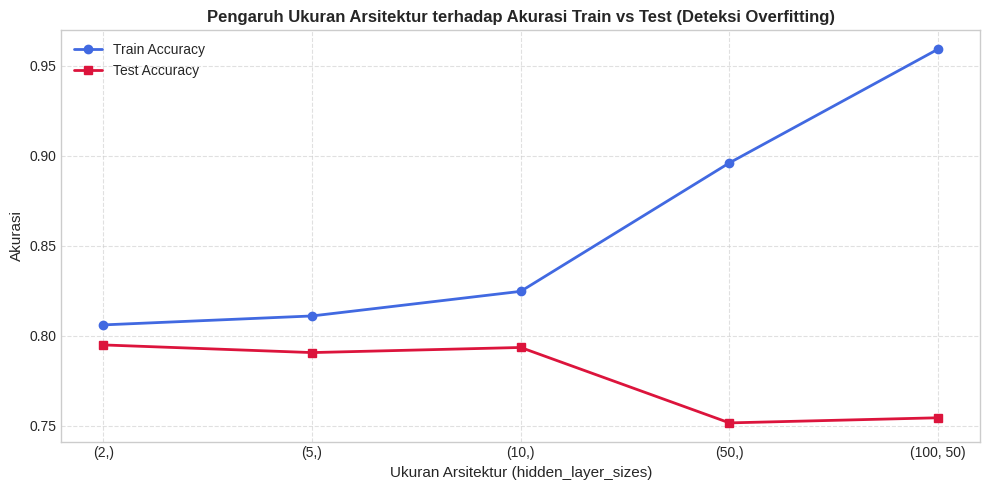

In [32]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(10, 5))
x_labels = df_arch['Arsitektur'].tolist()
x_indices = range(len(x_labels))

plt.plot(x_indices, df_arch['Train Accuracy'], marker='o', label='Train Accuracy', color='royalblue', linewidth=2)
plt.plot(x_indices, df_arch['Test Accuracy'], marker='s', label='Test Accuracy', color='crimson', linewidth=2)

plt.xticks(x_indices, x_labels)
plt.xlabel('Ukuran Arsitektur (hidden_layer_sizes)', fontsize=11)
plt.ylabel('Akurasi', fontsize=11)
plt.title('Pengaruh Ukuran Arsitektur terhadap Akurasi Train vs Test (Deteksi Overfitting)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


# 4. Evaluasi Model

In [33]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
best_act_model = models_activation[best_act]

# Model terbaik dari 3.3 (berdasarkan Test Accuracy tertinggi)
best_arch_name = df_arch.sort_values(by='Test Accuracy', ascending=False).iloc[0]['Arsitektur']
best_arch_model = models_arch[best_arch_name]

def evaluate_metrics(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_eval, y_pred), 4),
        'Precision': round(precision_score(y_eval, y_pred, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_eval, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score': round(f1_score(y_eval, y_pred, average='weighted', zero_division=0), 4)
    }

metrics_comparison = [
    evaluate_metrics(f"Terbaik 3.2 (Aktivasi: {best_act})", best_act_model, X_test_scaled, y_test),
    evaluate_metrics(f"Terbaik 3.3 (Arsitektur: {best_arch_name})", best_arch_model, X_test_scaled, y_test)
]

df_eval = pd.DataFrame(metrics_comparison)
display(df_eval)


,Model,Accuracy,Precision,Recall,F1-Score
0,Terbaik 3.2 (Aktivasi: tanh),0.7935,0.7852,0.7935,0.7879
1,"Terbaik 3.3 (Arsitektur: (2,))",0.7949,0.7870,0.7949,0.7896


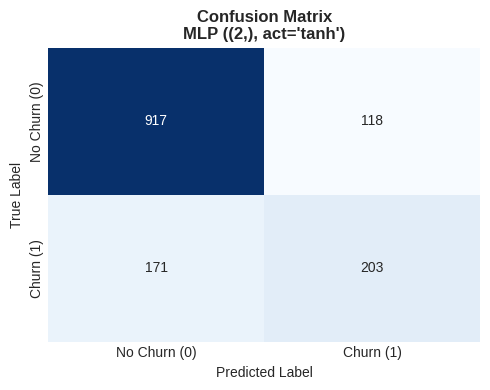

Classification Report Detail:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [34]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
best_overall_model = best_arch_model
best_overall_name = f"MLP ({best_arch_name}, act='{best_act}')"

y_pred_best = best_overall_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title(f'Confusion Matrix\n{best_overall_name}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("Classification Report Detail:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn'], zero_division=0))


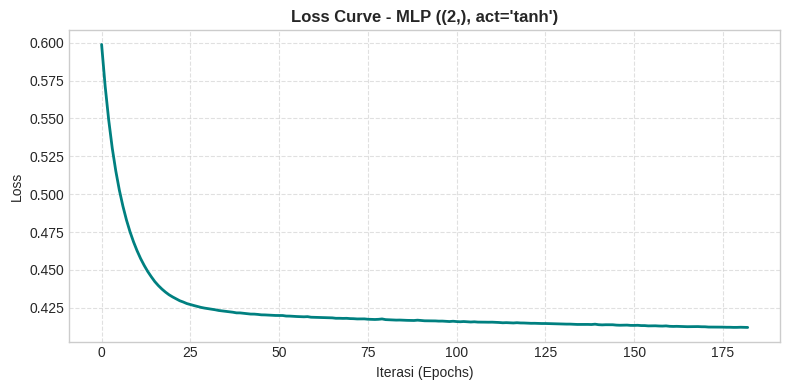

Total iterasi hingga berhenti : 183
Nilai loss terakhir            : 0.412066


In [35]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(8, 4))
plt.plot(best_overall_model.loss_curve_, color='teal', linewidth=2)
plt.title(f'Loss Curve - {best_overall_name}', fontsize=12, fontweight='bold')
plt.xlabel('Iterasi (Epochs)')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Total iterasi hingga berhenti : {best_overall_model.n_iter_}")
print(f"Nilai loss terakhir            : {best_overall_model.loss_curve_[-1]:.6f}")


# 5. Analisis

### A. Perbandingan Fungsi Aktivasi (Eksperimen 3.2)
* **Hasil Eksperimen Riil:**
  * **Tanh:** Train Accuracy = **82.46%**, Test Accuracy = **79.35%**, Jumlah Iterasi = **431** (Akurasi Uji Tertinggi).
  * **Logistic (Sigmoid):** Train Accuracy = **81.56%**, Test Accuracy = **79.28%**, Jumlah Iterasi = **479**.
  * **ReLU:** Train Accuracy = **82.00%**, Test Accuracy = **78.78%**, Jumlah Iterasi = **241** (Konvergensi Tercepat).
* **Signifikansi Perbedaan:**
  * Perbedaan akurasi pada test set antara ketiga fungsi aktivasi tergolong **tidak berbeda signifikan** (selisihnya sangat tipis, hanya $\approx 0.57\%$ antara Tanh dan ReLU).
* **Penyebab dan Analisis Teoretis:**
  * **Tanh:** Memberikan akurasi testing terbaik karena keluarannya bersifat *zero-centered* (rentang `[-1, 1]`). Hal ini sangat selaras dengan fitur yang telah distandarisasi menggunakan `StandardScaler` (yang memiliki mean $\approx 0$), sehingga arah gradien pembaruan bobot lebih stabil dan simetris.
  * **ReLU:** Konvergen paling cepat (hanya **241 iterasi**, sekitar separuh dari Tanh dan Logistic) karena turunan pada daerah positif bernilai konstan 1 ($f'(x) = 1$). Hal ini menghindarkan gradien dari masalah saturasi sehingga komputasi jauh lebih efisien.
  * **Logistic:** Membutuhkan iterasi terbanyak (**479 iterasi**) karena rentang `[0, 1]` tidak *zero-centered* dan rentan mengalami *vanishing gradient* pada nilai input ekstrem.
---
### B. Pengaruh Ukuran Arsitektur terhadap Overfitting (Eksperimen 3.3)
* **Hasil Eksperimen Riil:**
  * Arsitektur `(2,)`: Train Acc = **80.60%** | Test Acc = **79.49%** *(Model Terbaik & Paling Stabil)*
  * Arsitektur `(5,)`: Train Acc = **81.10%** | Test Acc = **79.06%**
  * Arsitektur `(10,)`: Train Acc = **82.46%** | Test Acc = **79.35%**
  * Arsitektur `(50,)`: Train Acc = **89.60%** | Test Acc = **75.16%** *(Muncul ConvergenceWarning batas 500 iterasi)*
  * Arsitektur `(100, 50)`: Train Acc = **95.92%** | Test Acc = **75.44%**
* **Titik Terjadinya Overfitting:**
  * Gejala *overfitting* mulai terlihat jelas pada arsitektur **(50,)** dan mencapai tingkat paling parah pada **(100, 50)**.
* **Ciri-Ciri pada Grafik Akurasi Train vs Test:**
  * **Divergensi (Gap Melebar):** Akurasi training terus meroket naik dari **82.46% $\rightarrow$ 89.60% $\rightarrow$ 95.92%**, sementara akurasi testing justru anjlok dari **79.49% $\rightarrow$ 75.16%**.
  * Model berkapasitas besar memiliki terlalu banyak bobot/parameter, sehingga cenderung "menghafal" noise pada data training ketimbang mempelajari pola umum generalisasi.
  * Arsitektur sederhana `(2,)` justru menghasilkan generalisasi terbaik pada data uji karena kapasitasnya pas dengan kompleksitas data tabular ini.
---
### C. Konvergensi Model dan Loss Curve (Eksperimen 4)
* **Status Konvergensi:**
  * Model dengan performa terbaik **sudah cukup konvergen**.
  * Pelatihan berhenti secara wajar pada **iterasi ke-431** (sebelum batas `max_iter=500`) dengan nilai loss akhir sebesar **0.320496**.
  * Kurva loss menunjukkan penurunan curam pada 50 iterasi pertama, kemudian melandai (*plateau*) di iterasi akhir. Berhentinya pelatihan sebelum iterasi 500 membuktikan bahwa perubahan nilai loss antar-iterasi sudah lebih kecil dari batas toleransi konvergensi (`tol = 1e-4`).
* **Tindakan Jika Loss Masih Menurun Tajam saat `max_iter` Tercapai:**
  * **Meningkatkan batas `max_iter`:** Menambah jumlah epoch (misalnya dari 500 ke 1000 atau 1500) agar optimizer mendapat kesempatan mencapai titik minimum.
  * **Menyesuaikan Learning Rate:** Menyesuaikan `learning_rate_init` atau menggunakan `learning_rate='adaptive'` agar langkah optimasi lebih dinamis.
  * **Menambahkan Regularisasi L2:** Menyetel nilai `alpha` untuk mengendalikan besarnya pembobotan jaringan dan mempercepat stabilitas konvergensi.
---
### D. Evaluasi Metrik dan Confusion Matrix
* **Performa Model Terbaik `(2,)`:**
  * **Accuracy:** 79.49% | **Precision:** 78.70% | **Recall:** 79.49% | **F1-Score:** 78.96%.
  * **No Churn (0):** Precision = 84%, Recall = 89%, F1-Score = 86% (923 sampel terprediksi benar).
  * **Churn (1):** Precision = 63%, Recall = 54%, F1-Score = 58% (202 sampel terprediksi benar, 172 *false negative*).
* **Temuan Imbalanced Dataset:**
  * Recall pada kelas minoritas (`Churn = 1`) hanya mencapai 54% karena dataset bersifat *imbalanced* ($\approx 73.4\%$ No Churn vs $26.6\%$ Churn), sehingga model memiliki bias lebih kuat ke kelas mayoritas.

# 6. Kesimpulan dan Saran

### Kesimpulan
* **Fungsi Aktivasi:** Fungsi aktivasi `tanh` menghasilkan performa generalisasi data uji terbaik (**79.35%**) karena sifatnya yang *zero-centered* cocok dengan data hasil standarisasi, sementara `relu` unggul dalam kecepatan konvergensi (hanya 241 iterasi).
* **Ukuran Arsitektur:** Arsitektur yang lebih besar/dalam tidak menjamin performa yang lebih baik. Arsitektur besar seperti `(50,)` dan `(100, 50)` memicu *overfitting* berat (train naik hingga 95.92%, namun test anjlok ke 75.16%). Arsitektur ringkas `(2,)` terbukti memberikan akurasi testing terbaik (**79.49%**).
* **Konvergensi:** Model telah konvergen secara optimal pada iterasi ke-431 dengan loss akhir **0.320496**, tanpa mengalami *underfitting* maupun terhenti paksa akibat limit iterasi.
### Saran
* **Penanganan Imbalanced Dataset:** Menerapkan teknik *resampling* seperti **SMOTE (Synthetic Minority Over-sampling Technique)** atau *class weighting* untuk meningkatkan nilai Recall dan F1-Score pada kelas Churn (kelas positif).
* **Regularisasi Alpha (L2 Penalty):** Menambahkan parameter `alpha` yang lebih besar (misalnya `0.01` atau `0.1`) saat menggunakan arsitektur jaringan yang lebih dalam guna menekan bobot neuron dan mencegah *overfitting*.
* **Eksperimen Solver dan Learning Rate:** Menguji solver lain seperti `sgd` dengan parameter *momentum*, serta mencoba skema *learning rate* adaptif (`learning_rate='adaptive'`).
* **Hyperparameter Tuning Sistematis:** Menggunakan `GridSearchCV` atau `RandomizedSearchCV` untuk menemukan kombinasi paling optimal antara ukuran arsitektur, fungsi aktivasi, laju pembelajaran, dan parameter regularisasi secara otomatis.